In [1]:
import json
import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

_cwd = Path.cwd()
if not (_cwd / "data").exists() and (_cwd.parent / "data").exists():
    os.chdir(_cwd.parent)
print(f"working directory: {Path.cwd()}")
%matplotlib inline

working directory: C:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
TRAIN_IMAGE_DIR = Path("data/training/image")
TRAIN_JSON_PATH = Path("data/training/train.json")
TEST_IMAGE_DIR = Path("data/testing/images")
TEST_JSON_PATH = Path("data/testing/test.json")

for p in [TRAIN_IMAGE_DIR, TRAIN_JSON_PATH, TEST_IMAGE_DIR, TEST_JSON_PATH]:
    assert p.exists(), f"missing: {p}"

print("=== DATASET PATHS ===")
print(f"train images : {TRAIN_IMAGE_DIR}")
print(f"train labels : {TRAIN_JSON_PATH}")
print(f"test images  : {TEST_IMAGE_DIR}")
print(f"test labels  : {TEST_JSON_PATH}")

=== DATASET PATHS ===
train images : data\training\image
train labels : data\training\train.json
test images  : data\testing\images
test labels  : data\testing\test.json


In [3]:
with TRAIN_JSON_PATH.open() as f:
    train_labels = json.load(f)
with TEST_JSON_PATH.open() as f:
    test_labels = json.load(f)

print("=== JSON FILE PURPOSE ===")
print("Each JSON file is a flat {filename: quality_score} mapping -- one")
print("entry per CT image, giving that image's radiologist-derived quality score.")
print()
print(f"train.json: {len(train_labels)} entries, type={type(train_labels).__name__}")
print("first 5 entries:")
for k, v in list(train_labels.items())[:5]:
    print(f"    {k!r}: {v!r}")
print()
print(f"test.json: {len(test_labels)} entries, type={type(test_labels).__name__}")
print("first 5 entries:")
for k, v in list(test_labels.items())[:5]:
    print(f"    {k!r}: {v!r}")

=== JSON FILE PURPOSE ===
Each JSON file is a flat {filename: quality_score} mapping -- one
entry per CT image, giving that image's radiologist-derived quality score.

train.json: 1000 entries, type=dict
first 5 entries:
    '0000.tif': 2.8
    '0001.tif': 1.8
    '0002.tif': 3.4
    '0003.tif': 2.0
    '0004.tif': 2.0

test.json: 300 entries, type=dict
first 5 entries:
    'test000.tiff': 2.6666666666666665
    'test001.tiff': 1.1666666666666667
    'test002.tiff': 0.5
    'test003.tiff': 2.8333333333333335
    'test004.tiff': 1.5


In [4]:
def list_files_by_extension(directory):
    counts = Counter(p.suffix.lower() for p in directory.iterdir() if p.is_file())
    return counts

train_ext_counts = list_files_by_extension(TRAIN_IMAGE_DIR)
test_ext_counts = list_files_by_extension(TEST_IMAGE_DIR)

print("=== FILE EXTENSIONS ON DISK ===")
print(f"training/image/  : {dict(train_ext_counts)}")
print(f"testing/images/  : {dict(test_ext_counts)}")
print()
print("Non-image metadata files (e.g. .DS_Store) would show up here as an")
print("extension outside {.tif, .tiff} -- none were found in either directory.")

=== FILE EXTENSIONS ON DISK ===
training/image/  : {'.tif': 1000}
testing/images/  : {'.tiff': 300}

Non-image metadata files (e.g. .DS_Store) would show up here as an
extension outside {.tif, .tiff} -- none were found in either directory.


In [5]:
VALID_EXTENSIONS = (".tif", ".tiff")

def image_filenames(directory):
    return {p.name for p in directory.iterdir() if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS}

train_image_files = image_filenames(TRAIN_IMAGE_DIR)
test_image_files = image_filenames(TEST_IMAGE_DIR)

train_images_without_label = train_image_files - train_labels.keys()
train_labels_without_image = train_labels.keys() - train_image_files
test_images_without_label = test_image_files - test_labels.keys()
test_labels_without_image = test_labels.keys() - test_image_files

print("=== IMAGE <-> LABEL CONSISTENCY ===")
print(f"training images on disk : {len(train_image_files)}")
print(f"training JSON entries   : {len(train_labels)}")
print(f"training images with no label : {len(train_images_without_label)}")
print(f"training labels with no image : {len(train_labels_without_image)}")
print()
print(f"testing images on disk : {len(test_image_files)}")
print(f"testing JSON entries   : {len(test_labels)}")
print(f"testing images with no label : {len(test_images_without_label)}")
print(f"testing labels with no image : {len(test_labels_without_image)}")
print()
assert not train_images_without_label and not train_labels_without_image
assert not test_images_without_label and not test_labels_without_image
print("Every image has exactly one label and every label has exactly one image, in both splits.")

=== IMAGE <-> LABEL CONSISTENCY ===
training images on disk : 1000
training JSON entries   : 1000
training images with no label : 0
training labels with no image : 0

testing images on disk : 300
testing JSON entries   : 300
testing images with no label : 0
testing labels with no image : 0

Every image has exactly one label and every label has exactly one image, in both splits.


In [6]:
def inspect_images(directory, filenames, sample_size=None):
    names = sorted(filenames)
    if sample_size is not None:
        names = names[:sample_size]
    modes, sizes, dtypes = Counter(), Counter(), Counter()
    px_min, px_max = float("inf"), float("-inf")
    for name in names:
        with Image.open(directory / name) as im:
            modes[im.mode] += 1
            sizes[im.size] += 1
            arr = np.array(im)
            dtypes[str(arr.dtype)] += 1
            px_min = min(px_min, float(arr.min()))
            px_max = max(px_max, float(arr.max()))
    return modes, sizes, dtypes, px_min, px_max

train_modes, train_sizes, train_dtypes, train_px_min, train_px_max = inspect_images(TRAIN_IMAGE_DIR, train_image_files)
test_modes, test_sizes, test_dtypes, test_px_min, test_px_max = inspect_images(TEST_IMAGE_DIR, test_image_files)

print("=== IMAGE PROPERTIES ===")
print("training:")
print(f"    PIL mode(s): {dict(train_modes)}")
print(f"    size(s)    : {dict(train_sizes)}")
print(f"    dtype(s)   : {dict(train_dtypes)}")
print(f"    pixel range: [{train_px_min}, {train_px_max}]")
print("testing:")
print(f"    PIL mode(s): {dict(test_modes)}")
print(f"    size(s)    : {dict(test_sizes)}")
print(f"    dtype(s)   : {dict(test_dtypes)}")
print(f"    pixel range: [{test_px_min}, {test_px_max}]")

=== IMAGE PROPERTIES ===
training:
    PIL mode(s): {'F': 1000}
    size(s)    : {(512, 512): 1000}
    dtype(s)   : {'float32': 1000}
    pixel range: [0.0, 1.0]
testing:
    PIL mode(s): {'F': 300}
    size(s)    : {(512, 512): 300}
    dtype(s)   : {'float32': 300}
    pixel range: [0.0, 1.0]


In [7]:
import hashlib

def find_duplicate_images(directory, filenames):
    seen = {}
    duplicates = []
    for name in sorted(filenames):
        with Image.open(directory / name) as im:
            digest = hashlib.md5(np.array(im).tobytes()).hexdigest()
        if digest in seen:
            duplicates.append((name, seen[digest]))
        else:
            seen[digest] = name
    return duplicates

train_duplicates = find_duplicate_images(TRAIN_IMAGE_DIR, train_image_files)
test_duplicates = find_duplicate_images(TEST_IMAGE_DIR, test_image_files)

print("=== DUPLICATE IMAGE CHECK (exact pixel match) ===")
print(f"training duplicates: {len(train_duplicates)} {train_duplicates[:5]}")
print(f"testing duplicates : {len(test_duplicates)} {test_duplicates[:5]}")

=== DUPLICATE IMAGE CHECK (exact pixel match) ===
training duplicates: 0 []
testing duplicates : 0 []


In [8]:
train_scores = np.array(list(train_labels.values()))
test_scores = np.array(list(test_labels.values()))

print("=== SCORE STATISTICS ===")
for name, scores in [("train", train_scores), ("test", test_scores)]:
    print(f"{name}: n={len(scores)}  min={scores.min():.4f}  max={scores.max():.4f}  "
          f"mean={scores.mean():.4f}  std={scores.std():.4f}  unique_values={len(np.unique(scores.round(6)))}")

=== SCORE STATISTICS ===
train: n=1000  min=0.0000  max=4.0000  mean=2.0728  std=1.0662  unique_values=21
test: n=300  min=0.0000  max=4.0000  mean=2.1311  std=1.0871  unique_values=25


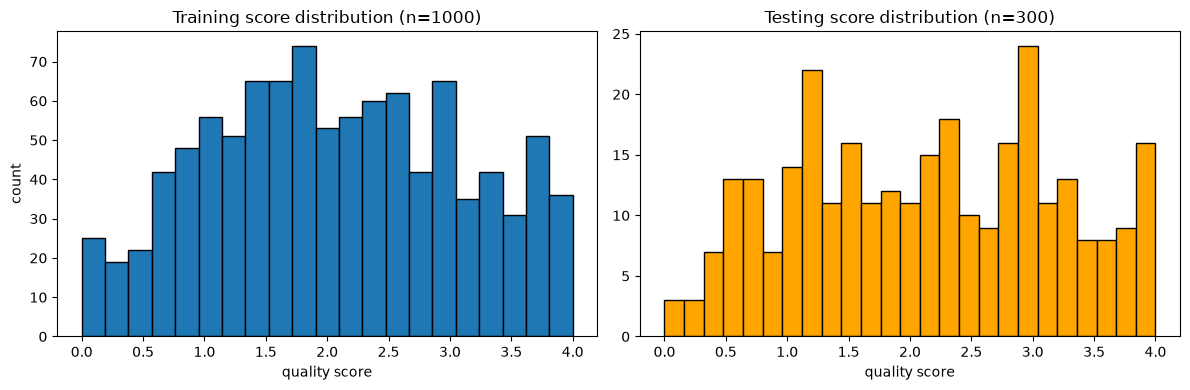

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_scores, bins=21, edgecolor="black")
axes[0].set_title(f"Training score distribution (n={len(train_scores)})")
axes[0].set_xlabel("quality score")
axes[0].set_ylabel("count")

axes[1].hist(test_scores, bins=25, edgecolor="black", color="orange")
axes[1].set_title(f"Testing score distribution (n={len(test_scores)})")
axes[1].set_xlabel("quality score")
plt.tight_layout()
plt.show()

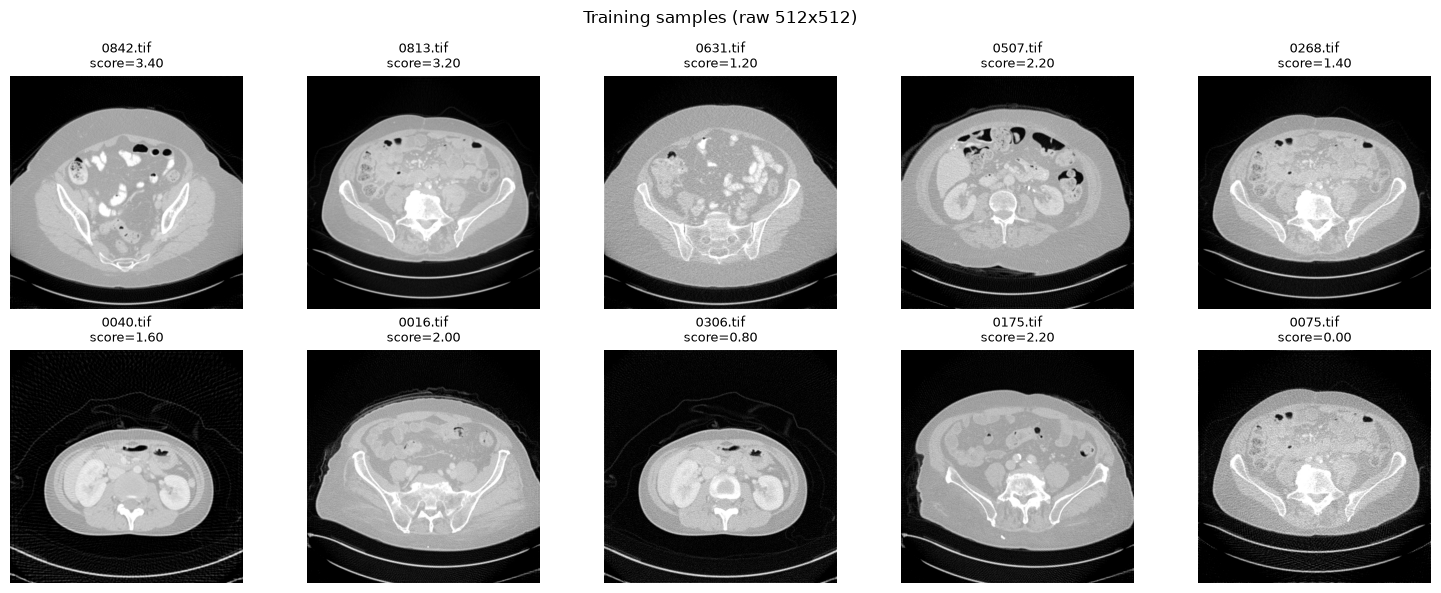

In [10]:
def show_sample_grid(directory, labels, title, n_rows=2, n_cols=5, seed=0):
    rng = np.random.default_rng(seed)
    filenames = rng.choice(sorted(labels.keys()), size=n_rows * n_cols, replace=False)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    for ax, fn in zip(axes.flat, filenames):
        with Image.open(directory / fn) as im:
            arr = np.array(im)
        ax.imshow(arr, cmap="gray")
        ax.set_title(f"{fn}\nscore={labels[fn]:.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_sample_grid(TRAIN_IMAGE_DIR, train_labels, "Training samples (raw 512x512)")

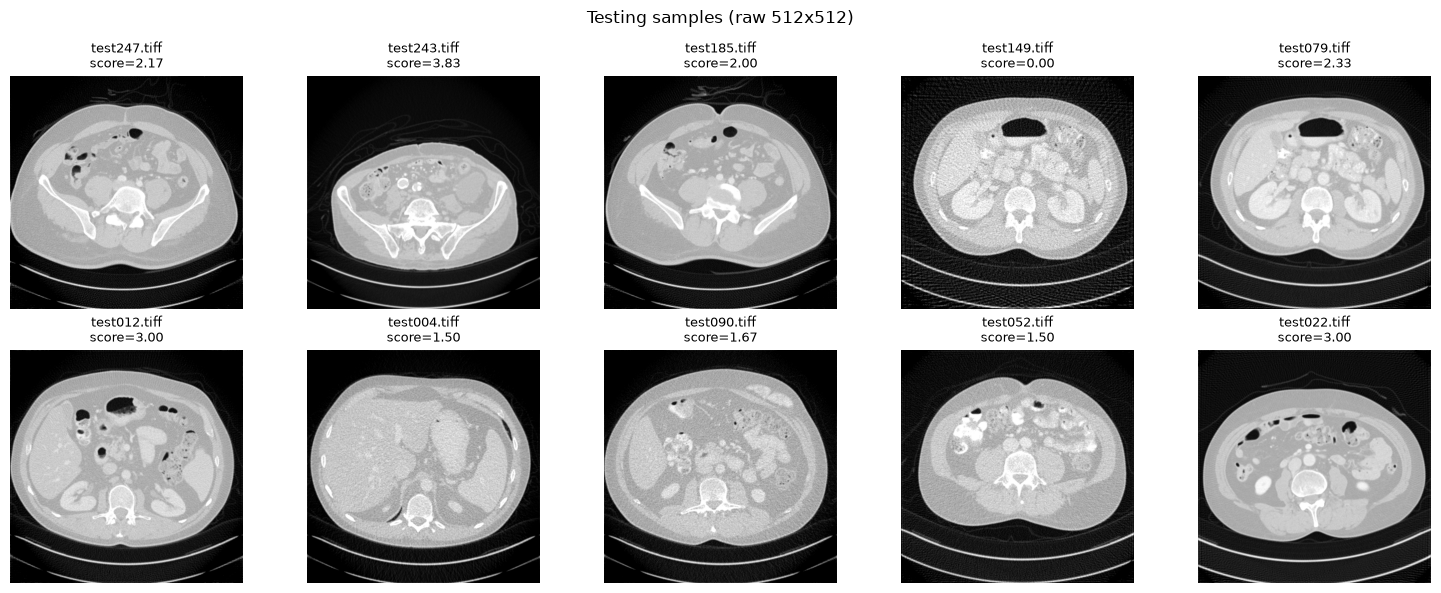

In [11]:
show_sample_grid(TEST_IMAGE_DIR, test_labels, "Testing samples (raw 512x512)")

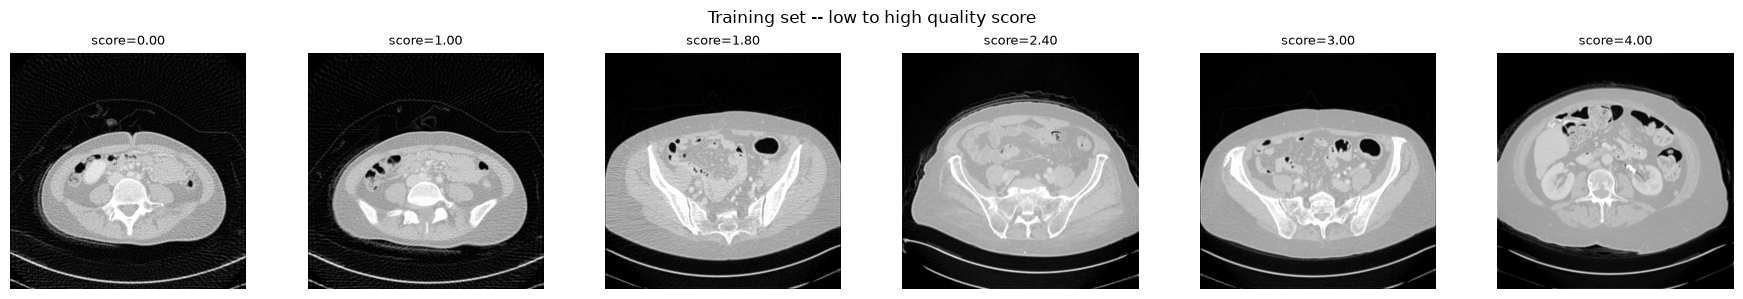

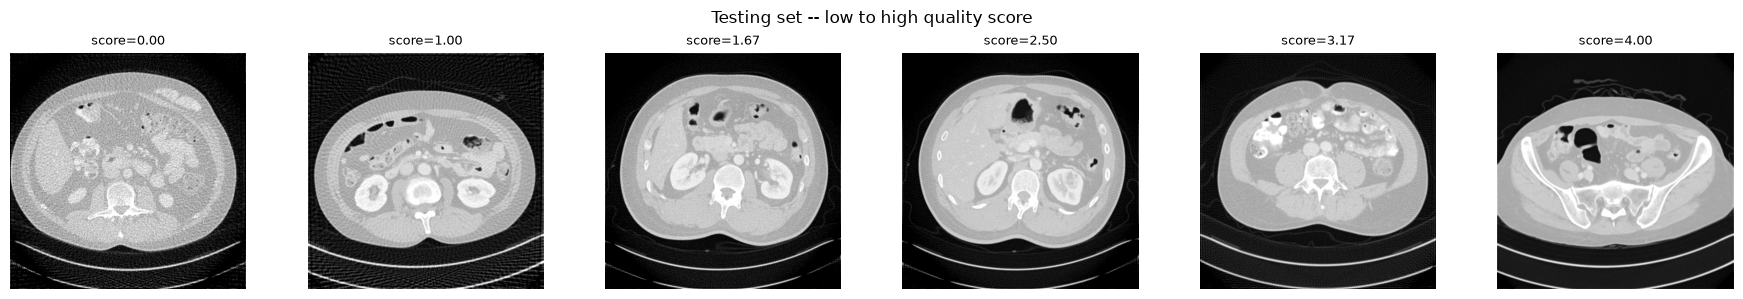

In [12]:
def show_score_range_examples(directory, labels, title, n_examples=6):
    sorted_items = sorted(labels.items(), key=lambda kv: kv[1])
    indices = np.linspace(0, len(sorted_items) - 1, n_examples).astype(int)
    picks = [sorted_items[i] for i in indices]

    fig, axes = plt.subplots(1, n_examples, figsize=(3 * n_examples, 3))
    for ax, (fn, score) in zip(axes, picks):
        with Image.open(directory / fn) as im:
            arr = np.array(im)
        ax.imshow(arr, cmap="gray")
        ax.set_title(f"score={score:.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"{title} -- low to high quality score")
    plt.tight_layout()
    plt.show()

show_score_range_examples(TRAIN_IMAGE_DIR, train_labels, "Training set")
show_score_range_examples(TEST_IMAGE_DIR, test_labels, "Testing set")

In [13]:
print("=== EDA SUMMARY ===")
print(f"training: {len(train_labels)} image/label pairs, score range [{train_scores.min():.2f}, {train_scores.max():.2f}]")
print(f"testing : {len(test_labels)} image/label pairs, score range [{test_scores.min():.2f}, {test_scores.max():.2f}]")
print(f"image format: TIFF, PIL mode 'F' (32-bit float), 512x512, pixel range [0, 1]")
print(f"train.json / test.json each map filename -> quality score; no other fields.")
print(f"no missing labels, no orphan images, no duplicate images, no non-image files found.")

=== EDA SUMMARY ===
training: 1000 image/label pairs, score range [0.00, 4.00]
testing : 300 image/label pairs, score range [0.00, 4.00]
image format: TIFF, PIL mode 'F' (32-bit float), 512x512, pixel range [0, 1]
train.json / test.json each map filename -> quality score; no other fields.
no missing labels, no orphan images, no duplicate images, no non-image files found.
